<a href="https://colab.research.google.com/github/Basmala135/grad_project/blob/main/grad_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
os.makedirs("data/raw/boubezoul", exist_ok=True)
os.makedirs("data/raw/normal_riding", exist_ok=True)

In [5]:
# ── Config ─────────────────────────────────────────────────────────────────
SAMPLE_RATE   = 100          # Hz — MPU-9250 sampling rate
WINDOW_SEC    = 2.0          # seconds per window
OVERLAP       = 0.5          # 50% overlap between windows
WINDOW_SIZE   = int(SAMPLE_RATE * WINDOW_SEC)   # = 200 samples
STEP_SIZE     = int(WINDOW_SIZE * (1 - OVERLAP)) # = 100 samples
CHANNELS      = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']  # 6 IMU channels

RAW_DIR       = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
# ── Column name mapping ─────────────────────────────────────────────────────
# Boubezoul dataset uses these column names — adjust if yours differ
BOUBEZOUL_COLS = {
    'Ax(m/s²)': 'ax', 'Ay(m/s²)': 'ay', 'Az(m/s²)': 'az',
    'Rx(°/s)': 'gx', 'Ry.(°/s)': 'gy', 'Rz(°/s)': 'gz',
}

def load_csv_folder(folder: Path, col_map: dict = None):
    arrays = []
    for f in sorted(folder.glob("*.csv")):

        # Try tab-separated first (Boubezoul)
        try:
            df = pd.read_csv(f, encoding='latin1', sep='\t')
            if len(df.columns) == 1:
                raise Exception("Wrong separator")
        except:
            # Fallback to comma-separated (normal data)
            df = pd.read_csv(f, encoding='latin1')

        df.columns = df.columns.str.strip()

        if col_map:
            df = df.rename(columns=col_map)

        # Convert to numeric
        for col in CHANNELS:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df[CHANNELS].dropna().reset_index(drop=True)

        arrays.append(df.values.astype(np.float32))
        print(f"  Loaded {f.name}: {len(df)} samples")

    return arrays


def sliding_windows(data: np.ndarray, label: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Slice a (N, 6) array into overlapping windows.
    Returns X of shape (num_windows, WINDOW_SIZE, 6) and y of shape (num_windows,).
    """
    X, y = [], []
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data[start : start + WINDOW_SIZE]
        X.append(window)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int8)


def normalize(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Per-channel z-score normalization. Returns normalized X, mean, std."""
    mean = X.mean(axis=(0, 1), keepdims=True)   # shape (1, 1, 6)
    std  = X.std(axis=(0, 1), keepdims=True) + 1e-8
    return (X - mean) / std, mean.squeeze(), std.squeeze()


def main():
    print("Loading ACCIDENT data (label=1)...")
    accident_arrays = load_csv_folder(RAW_DIR / "boubezoul", BOUBEZOUL_COLS)

    print("\nLoading NORMAL RIDING data (label=0)...")
    normal_arrays = load_csv_folder(RAW_DIR / "normal_riding")

    # Segment into windows
    print("\nSegmenting into windows...")
    X_acc, y_acc = [], []
    for arr in accident_arrays:
        x, y = sliding_windows(arr, label=1)
        X_acc.append(x); y_acc.append(y)

    X_nor, y_nor = [], []
    for arr in normal_arrays:
        x, y = sliding_windows(arr, label=0)
        X_nor.append(x); y_nor.append(y)

    X = np.concatenate(X_acc + X_nor, axis=0)
    y = np.concatenate(y_acc + y_nor, axis=0)

    print(f"\nTotal windows: {len(X)}  (accident={y.sum()}, normal={len(y)-y.sum()})")

    # Normalize
    X, mean, std = normalize(X)
    np.save(PROCESSED_DIR / "norm_mean.npy", mean)
    np.save(PROCESSED_DIR / "norm_std.npy",  std)
    print(f"Saved normalization stats → data/processed/norm_mean.npy, norm_std.npy")
    print(f"  These MUST be flashed to the ESP32 for inference.")

    # Train / val / test split (70 / 15 / 15)
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv)

    np.save(PROCESSED_DIR / "X_train.npy", X_train)
    np.save(PROCESSED_DIR / "y_train.npy", y_train)
    np.save(PROCESSED_DIR / "X_val.npy",   X_val)
    np.save(PROCESSED_DIR / "y_val.npy",   y_val)
    np.save(PROCESSED_DIR / "X_test.npy",  X_test)
    np.save(PROCESSED_DIR / "y_test.npy",  y_test)

    print(f"\nSplit sizes:")
    print(f"  Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"\nDone. Run 02_augment.py next.")

In [21]:
if __name__ == "__main__":
    main()

Loading ACCIDENT data (label=1)...
  Loaded Acceleration On Curve.csv: 47935 samples


/tmp/ipykernel_5683/853465640.py:14: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='latin1', sep='\t')
/tmp/ipykernel_5683/853465640.py:14: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='latin1', sep='\t')


  Loaded Acceleration On Straight Line.csv: 138303 samples


/tmp/ipykernel_5683/853465640.py:14: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='latin1', sep='\t')


  Loaded Fall Like manoeuvre 1.csv: 132478 samples


...

  Loaded Fall on a slippery straight road section.csv: 74045 samples
  Loaded Fall with leaning of the motorcycle.csv: 81663 samples


/tmp/ipykernel_5683/853465640.py:14: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='latin1', sep='\t')


  Loaded Harsh breaking On Straight Line.csv: 111485 samples


/tmp/ipykernel_5683/853465640.py:14: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding='latin1', sep='\t')


  Loaded Much degraded track.csv: 132094 samples

Loading NORMAL RIDING data (label=0)...
  Loaded normal.csv: 5102330 samples

Segmenting into windows...

Total windows: 62407  (accident=11385, normal=51022)
Saved normalization stats → data/processed/norm_mean.npy, norm_std.npy
  These MUST be flashed to the ESP32 for inference.

Split sizes:
  Train: 43709  Val: 9336  Test: 9362

Done. Run 02_augment.py next.


In [22]:
"""
Step 2 — Data augmentation
Expands the training set using physics-preserving transforms.
Only augments the ACCIDENT class (label=1) to fix class imbalance.
"""

import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
AUG_FACTOR    = 5   # how many augmented copies per original accident window

# ── Augmentation functions ──────────────────────────────────────────────────

def add_gaussian_noise(x: np.ndarray, sigma: float = 0.05) -> np.ndarray:
    """Add small random noise — simulates sensor noise and vibration variance."""
    return x + np.random.normal(0, sigma, x.shape).astype(np.float32)


def time_warp(x: np.ndarray, sigma: float = 0.2, knots: int = 4) -> np.ndarray:
    """
    Randomly speed up / slow down segments of the signal.
    Simulates variations in crash dynamics (e.g. slower vs faster falls).
    """
    from scipy.interpolate import CubicSpline
    orig_steps  = np.arange(len(x))
    warp_steps  = np.sort(np.random.choice(orig_steps[1:-1], knots, replace=False))
    warp_steps  = np.concatenate([[0], warp_steps, [len(x)-1]])
    warp_values = warp_steps + np.random.normal(0, sigma * len(x), len(warp_steps))
    warp_values[0] = 0; warp_values[-1] = len(x) - 1
    warp_values = np.sort(warp_values)
    warper = CubicSpline(warp_steps, warp_values)
    new_steps = np.clip(warper(orig_steps), 0, len(x) - 1)
    return np.array([
        np.interp(new_steps, orig_steps, x[:, ch])
        for ch in range(x.shape[1])
    ], dtype=np.float32).T


def scale_amplitude(x: np.ndarray, sigma: float = 0.15) -> np.ndarray:
    """
    Per-channel amplitude scaling.
    Simulates different sensor calibrations or crash intensities.
    """
    scale = np.random.normal(1.0, sigma, (1, x.shape[1])).astype(np.float32)
    return x * scale


def axis_permutation(x: np.ndarray) -> np.ndarray:
    """
    Swap/negate accelerometer or gyroscope axes.
    Simulates helmet being rotated slightly differently on each rider.
    Only swaps within accel group (0-2) and gyro group (3-5).
    """
    out = x.copy()
    # Random sign flip on accel
    for i in range(3):
        if np.random.rand() < 0.3:
            out[:, i] *= -1
    # Random sign flip on gyro
    for i in range(3, 6):
        if np.random.rand() < 0.3:
            out[:, i] *= -1
    return out


def augment_one(x: np.ndarray) -> np.ndarray:
    """Apply a random combination of augmentations to one window."""
    if np.random.rand() < 0.8:
        x = add_gaussian_noise(x)
    if np.random.rand() < 0.6:
        x = scale_amplitude(x)
    if np.random.rand() < 0.5:
        x = time_warp(x)
    if np.random.rand() < 0.4:
        x = axis_permutation(x)
    return x


# ── Main ────────────────────────────────────────────────────────────────────

def main():
    X_train = np.load(PROCESSED_DIR / "X_train.npy")
    y_train = np.load(PROCESSED_DIR / "y_train.npy")

    acc_idx = np.where(y_train == 1)[0]
    nor_idx = np.where(y_train == 0)[0]

    print(f"Before augmentation:")
    print(f"  Accident windows : {len(acc_idx)}")
    print(f"  Normal windows   : {len(nor_idx)}")

    aug_X, aug_y = [], []
    for idx in acc_idx:
        for _ in range(AUG_FACTOR):
            aug_X.append(augment_one(X_train[idx]))
            aug_y.append(1)

    aug_X = np.array(aug_X, dtype=np.float32)
    aug_y = np.array(aug_y, dtype=np.int8)

    X_aug = np.concatenate([X_train, aug_X], axis=0)
    y_aug = np.concatenate([y_train, aug_y], axis=0)

    # Shuffle
    perm  = np.random.permutation(len(X_aug))
    X_aug = X_aug[perm]
    y_aug = y_aug[perm]

    print(f"\nAfter augmentation:")
    print(f"  Accident windows : {(y_aug == 1).sum()}")
    print(f"  Normal windows   : {(y_aug == 0).sum()}")
    print(f"  Total            : {len(X_aug)}")

    np.save(PROCESSED_DIR / "X_train_aug.npy", X_aug)
    np.save(PROCESSED_DIR / "y_train_aug.npy", y_aug)
    print(f"\nSaved → data/processed/X_train_aug.npy, y_train_aug.npy")
    print("Run 03_train.py next.")



In [23]:

if __name__ == "__main__":
    main()

Before augmentation:
  Accident windows : 7974
  Normal windows   : 35735

After augmentation:
  Accident windows : 47844
  Normal windows   : 35735
  Total            : 83579

Saved → data/processed/X_train_aug.npy, y_train_aug.npy
Run 03_train.py next.


In [24]:
"""
Step 3 — Model training
Defines a compact 1D-CNN optimized for TFLite / ESP32 deployment
and trains it on the augmented dataset.

Model design constraints:
  - No LSTM (too slow on ESP32 without hardware acceleration)
  - No BatchNorm (adds overhead at inference time; use Dropout instead)
  - Total params < 50k to fit comfortably in ESP32 flash after quantization
  - Input shape: (200, 6) — 2 seconds at 100 Hz, 6 IMU channels
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("data/processed")
MODELS_DIR    = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

WINDOW_SIZE   = 200
N_CHANNELS    = 6
EPOCHS        = 60
BATCH_SIZE    = 32
LR            = 1e-3


# ── Model architecture ───────────────────────────────────────────────────────

def build_model() -> keras.Model:
    """
    3-block 1D-CNN with global average pooling.

    Block structure: Conv1D → ReLU → MaxPool → Dropout
    Ends with GAP + Dense(1) for binary classification.

    GAP instead of Flatten dramatically reduces parameter count
    and makes the model more robust to slight timing shifts in crash signals.
    """
    inp = keras.Input(shape=(WINDOW_SIZE, N_CHANNELS), name="imu_input")

    # Block 1 — catch short, sharp impulses (kernel=7 ~70ms at 100Hz)
    x = keras.layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)   # → (100, 32)
    x = keras.layers.Dropout(0.2)(x)

    # Block 2 — medium-duration patterns (kernel=5 ~50ms)
    x = keras.layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)   # → (50, 64)
    x = keras.layers.Dropout(0.2)(x)

    # Block 3 — longer context (kernel=3)
    x = keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)   # → (25, 64)
    x = keras.layers.Dropout(0.3)(x)

    # Global average pooling — replaces Flatten, keeps param count tiny
    x = keras.layers.GlobalAveragePooling1D()(x)    # → (64,)

    # Output — single sigmoid neuron (binary classification)
    out = keras.layers.Dense(1, activation='sigmoid', name="accident_prob")(x)

    model = keras.Model(inp, out, name="AccidentDetector_1DCNN")
    return model


# ── Training ─────────────────────────────────────────────────────────────────

def main():
    print("Loading data...")
    X_train = np.load(PROCESSED_DIR / "X_train_aug.npy")
    y_train = np.load(PROCESSED_DIR / "y_train_aug.npy")
    X_val   = np.load(PROCESSED_DIR / "X_val.npy")
    y_val   = np.load(PROCESSED_DIR / "y_val.npy")

    print(f"Train: {X_train.shape}  Val: {X_val.shape}")

    model = build_model()
    model.summary()
    print(f"\nTotal parameters: {model.count_params():,}")

    # Class weights handle remaining imbalance after augmentation
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    class_weight = {0: 1.0, 1: float(n_neg / n_pos)}
    print(f"Class weights → normal: 1.0, accident: {class_weight[1]:.2f}")

    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.BinaryAccuracy(name='acc'),
            keras.metrics.Recall(name='recall'),       # catch all real accidents
            keras.metrics.Precision(name='precision'),
        ]
    )

    callbacks = [
        # Save best model by validation recall — we care more about catching
        # every real accident than minimizing false alarms
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "best_model.keras",
            monitor='val_recall', mode='max',
            save_best_only=True, verbose=1
        ),
        # Reduce LR when recall plateaus
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_recall', mode='max',
            factor=0.5, patience=8, min_lr=1e-5, verbose=1
        ),
        # Early stopping on val_recall with a long patience
        keras.callbacks.EarlyStopping(
            monitor='val_recall', mode='max',
            patience=15, restore_best_weights=True, verbose=1
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric, title in zip(
        axes,
        ['loss', 'acc', 'recall'],
        ['Loss', 'Accuracy', 'Recall (accident detection rate)']
    ):
        ax.plot(history.history[metric],       label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Val')
        ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(MODELS_DIR / "training_curves.png", dpi=120)
    print(f"\nTraining curves saved → models/training_curves.png")
    print("Run 04_evaluate.py next.")



Loading data...
Train: (83579, 200, 6)  Val: (9336, 200, 6)


Model: "AccidentDetector_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 200, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ accident_prob (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,097 (94.13 KB)

 Trainable params: 24,097 (94.13 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 24,097
Class weights → normal: 1.0, accident: 0.75
Epoch 1/60
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9888 - loss: 0.0297 - precision: 0.9956 - recall: 0.9838
Epoch 1: val_recall improved from None to 1.00000, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 78s 29ms/step - acc: 0.9976 - loss: 0.0069 - precision: 0.9992 - recall: 0.9967 - val_acc: 0.9998 - val_loss: 0.0012 - val_precision: 0.9988 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
2611/2612 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9997 - loss: 6.1878e-04 - precision: 0.9998 - recall: 0.9997
Epoch 2: val_recall did not improve from 1.00000
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 76s 26ms/step - acc: 0.9998 - loss: 6.5017e-04 - precision: 0.9999 - recall: 0.9997 - val_acc: 1.0000 - val_loss: 6.2789e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
2612/2612 ━━━━━━━━━━━━━━━━━━━━ 0

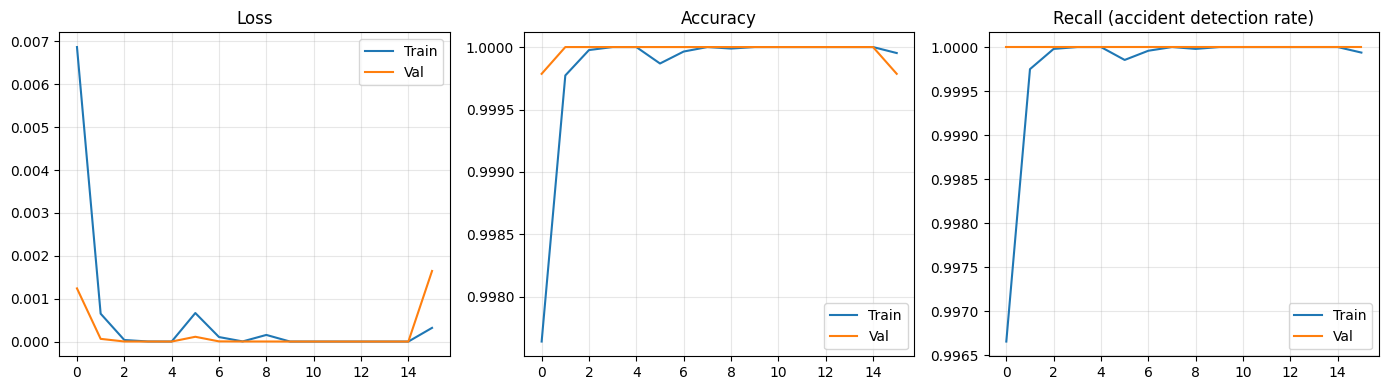

In [25]:

if __name__ == "__main__":
    main()

In [26]:
"""
Step 4 — Evaluation + TFLite export
Evaluates the best model on the held-out test set,
then converts it to a quantized TFLite model ready for the ESP32.

Two outputs:
  models/model_float32.tflite  ← baseline, for comparison
  models/model_int8.tflite     ← quantized, this goes on the ESP32
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("data/processed")
MODELS_DIR    = Path("models")
THRESHOLD     = 0.5   # decision boundary — raise to reduce false alarms


# ── Evaluation helpers ───────────────────────────────────────────────────────

def evaluate(model, X_test, y_test, label="Model"):
    y_prob = model.predict(X_test, verbose=0).squeeze()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Accident"]))

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"  Confusion matrix:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print(f"\n  False alarm rate (FPR): {fp/(fp+tn):.3f}  ← should be low")
    print(f"  Miss rate (FNR):        {fn/(fn+tp):.3f}  ← MUST be low, lives at stake")

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    roc    = roc_auc_score(y_test, y_prob)
    print(f"\n  ROC-AUC:  {roc:.4f}")
    print(f"  PR-AUC:   {pr_auc:.4f}")

    return y_prob, cm


def plot_confusion_matrix(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Accident"])
    ax.set_yticklabels(["Normal", "Accident"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    print(f"  Saved → {save_path}")


# ── TFLite conversion ────────────────────────────────────────────────────────

def convert_to_tflite(model, X_calib: np.ndarray) -> tuple[bytes, bytes]:
    """
    Convert to two TFLite variants:
      1. float32 — no quantization (reference)
      2. int8    — full integer quantization (ESP32 deployment)
    """
    # Float32 baseline
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    float_model = converter.convert()

    # Int8 quantization
    # Representative dataset feeds real training samples so TFLite can
    # compute per-tensor quantization scales for activations
    def representative_dataset():
        for i in range(min(300, len(X_calib))):
            yield [X_calib[i:i+1].astype(np.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    int8_model = converter.convert()

    return float_model, int8_model


def benchmark_tflite(tflite_model: bytes, X_test: np.ndarray, y_test: np.ndarray,
                     is_int8: bool = False) -> None:
    """Run TFLite interpreter to verify accuracy is preserved after quantization."""
    import time
    interp = tf.lite.Interpreter(model_content=tflite_model)
    interp.allocate_tensors()
    inp_details = interp.get_input_details()[0]
    out_details = interp.get_output_details()[0]

    preds = []
    t0 = time.perf_counter()
    for i in range(len(X_test)):
        sample = X_test[i:i+1]
        if is_int8:
            scale, zp = inp_details['quantization']
            sample = (sample / scale + zp).astype(np.int8)
        interp.set_tensor(inp_details['index'], sample)
        interp.invoke()
        out = interp.get_tensor(out_details['index'])
        if is_int8:
            scale, zp = out_details['quantization']
            out = (out.astype(np.float32) - zp) * scale
        preds.append(float(out.squeeze()))
    elapsed = (time.perf_counter() - t0) / len(X_test) * 1000

    y_pred = (np.array(preds) >= THRESHOLD).astype(int)
    from sklearn.metrics import accuracy_score, recall_score
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    kind = "Int8" if is_int8 else "Float32"
    print(f"  TFLite {kind}: acc={acc:.4f}  recall={rec:.4f}  avg_inference={elapsed:.2f}ms/window")


# ── Main ─────────────────────────────────────────────────────────────────────

def main():
    X_test  = np.load(PROCESSED_DIR / "X_test.npy")
    y_test  = np.load(PROCESSED_DIR / "y_test.npy")
    X_train = np.load(PROCESSED_DIR / "X_train_aug.npy")

    print("Loading best Keras model...")
    model = keras.models.load_model(MODELS_DIR / "best_model.keras")

    y_prob, cm = evaluate(model, X_test, y_test, "Keras float32 model")
    plot_confusion_matrix(cm, "Keras model — test set", MODELS_DIR / "cm_keras.png")

    # ── Threshold tuning tip ───────────────────────────────────────────────
    print("\n  Threshold tuning:")
    for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
        y_p = (y_prob >= thresh).astype(int)
        tp  = ((y_p == 1) & (y_test == 1)).sum()
        fp  = ((y_p == 1) & (y_test == 0)).sum()
        fn  = ((y_p == 0) & (y_test == 1)).sum()
        print(f"    thresh={thresh:.1f} → recall={tp/(tp+fn):.3f}  false_alarms={fp}")

    # ── TFLite conversion ──────────────────────────────────────────────────
    print("\nConverting to TFLite...")
    float_bytes, int8_bytes = convert_to_tflite(model, X_train[:300])

    float_path = MODELS_DIR / "model_float32.tflite"
    int8_path  = MODELS_DIR / "model_int8.tflite"
    float_path.write_bytes(float_bytes)
    int8_path.write_bytes(int8_bytes)

    print(f"\n  Float32 model: {len(float_bytes)/1024:.1f} KB → {float_path}")
    print(f"  Int8 model:    {len(int8_bytes)/1024:.1f} KB  → {int8_path}")
    print(f"\n  (ESP32 has ~1.5 MB flash available for model — you're well within limits)")

    print("\nBenchmarking TFLite models on test set...")
    benchmark_tflite(float_bytes, X_test, y_test, is_int8=False)
    benchmark_tflite(int8_bytes,  X_test, y_test, is_int8=True)

    # ── Generate C header for ESP32 ────────────────────────────────────────
    print("\nGenerating C header file for ESP32...")
    generate_c_header(int8_bytes, MODELS_DIR / "model_int8.h")
    print("Done! See models/model_int8.h")
    print("Next: run 05_generate_esp32_header.py or flash model_int8.h to ESP32.")


def generate_c_header(model_bytes: bytes, out_path: Path) -> None:
    """Convert .tflite bytes → C array header for inclusion in Arduino/ESP32 sketch."""
    arr = ", ".join(f"0x{b:02x}" for b in model_bytes)
    header = f"""// Auto-generated — do not edit
// TFLite int8 model for motorcycle accident detection
// Size: {len(model_bytes)} bytes ({len(model_bytes)/1024:.1f} KB)

#pragma once
#include <stdint.h>

const uint8_t accident_model_data[] = {{
  {arr}
}};
const unsigned int accident_model_data_len = {len(model_bytes)};
"""
    out_path.write_text(header)




Loading best Keras model...

  Keras float32 model
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7654
    Accident       1.00      1.00      1.00      1708

    accuracy                           1.00      9362
   macro avg       1.00      1.00      1.00      9362
weighted avg       1.00      1.00      1.00      9362

  Confusion matrix:
    TN=7648  FP=6
    FN=0  TP=1708

  False alarm rate (FPR): 0.001  ← should be low
  Miss rate (FNR):        0.000  ← MUST be low, lives at stake

  ROC-AUC:  1.0000
  PR-AUC:   1.0000
  Saved → models/cm_keras.png

  Threshold tuning:
    thresh=0.3 → recall=1.000  false_alarms=8
    thresh=0.4 → recall=1.000  false_alarms=8
    thresh=0.5 → recall=1.000  false_alarms=6
    thresh=0.6 → recall=1.000  false_alarms=6
    thresh=0.7 → recall=1.000  false_alarms=6

Converting to TFLite...
Saved artifact at '/tmp/tmpsh8qh237'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (P

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



  Float32 model: 101.2 KB → models/model_float32.tflite
  Int8 model:    35.8 KB  → models/model_int8.tflite

  (ESP32 has ~1.5 MB flash available for model — you're well within limits)

Benchmarking TFLite models on test set...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  TFLite Float32: acc=0.9994  recall=1.0000  avg_inference=0.08ms/window


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  TFLite Int8: acc=0.9974  recall=1.0000  avg_inference=0.10ms/window

Generating C header file for ESP32...
Done! See models/model_int8.h
Next: run 05_generate_esp32_header.py or flash model_int8.h to ESP32.


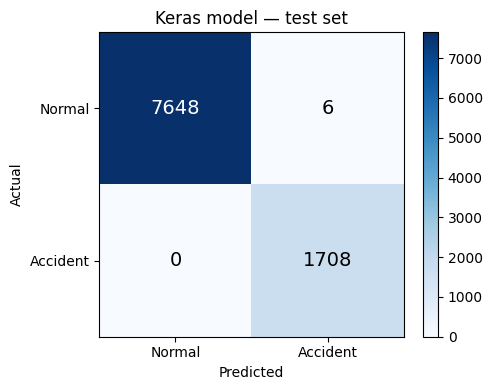

In [27]:
if __name__ == "__main__":
    main()